In [1]:
from pathlib import Path
import re
from collections import Counter
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import pandas as pd
import numpy as np

SZ: files=2522, tokens(after cleaning)=1172039
Zeit: files=6281, tokens(after cleaning)=4315585
Spiegel: files=9190, tokens(after cleaning)=4635716
TAZ: files=4629, tokens(after cleaning)=1953123
Welt: files=15109, tokens(after cleaning)=6139213


,SZ,Zeit,Spiegel,TAZ,Welt
word,,,,,
israel,9.706162,5.556605,6.444743,6.722567,11.219679
hamas,7.363236,3.487592,4.365453,4.323332,8.542300
deutschland,2.249925,2.470580,2.333836,2.160130,5.827457
menschen,3.906013,3.486202,3.542279,3.848196,3.115057
gaza,5.548450,1.951531,2.515469,3.704836,4.387044
krieg,3.889802,1.778438,2.038089,2.035714,3.586127
trump,0.682571,2.073184,2.373743,1.307137,2.893042
israelischen,2.772945,1.726070,2.293281,2.456579,2.314303
israels,2.795982,1.509413,2.190600,1.763330,2.128286


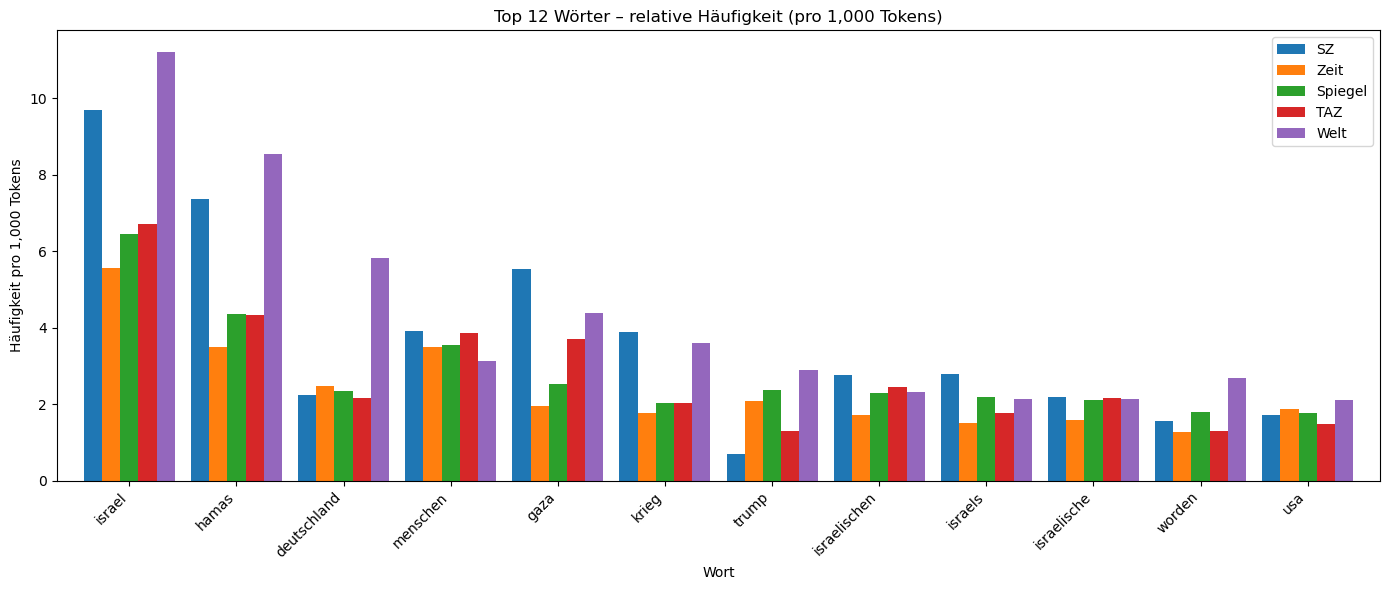


Top distinctive words per journal (delta vs mean of other journals):


,journal,word,delta_vs_others
1595296,Welt,israel,4.112160
1595298,Welt,hamas,3.657397
1237427,TAZ,nen,3.592092
1595834,Welt,deutschland,3.523839
1234039,TAZ,taz,2.854648
...,...,...,...
1521434,TAZ,küppersbusch,0.276480
1292465,TAZ,lis,0.273691
798288,Spiegel,hätten,0.270681
800046,Spiegel,könnte,0.269208


In [4]:
# =========================
# CONFIG
# =========================
BASE_DIR = Path("/home/arabella/Desktop/Journals")
# Example structure:
# /raw/
#   sz_txt/
#   faz_txt/
#   taz_txt/

JOURNAL_DIRS = {
    "SZ": BASE_DIR / "sz_txt",
     "Zeit": BASE_DIR / "diezeit_txt_clean",
     "Spiegel": BASE_DIR / "derspiegel_txt_clean",
    "TAZ": BASE_DIR / "taz_txt_clean",
    "Welt": BASE_DIR / "diewelt_txt_clean",
}
MAX_FILES = None  # None = all
TOP_N = 12
NORM_PER = 1_000  # relative frequency: occurrences per 10,000 tokens

STOPWORDS = {
    "der", "die", "zeit","das","spiegel", "ein", "eine", "einer", "eines", "einem", "einen","was","sagt","sei", "soll","muss",
    "und", "oder", "aber", "wenn", "dann", "denn", "dem","für", "mit", "ohne", "gegen", "über", "unter", "zwischen", "hat",
    "zu", "zum", "zur", "von", "vom", "im", "in", "am", "an", "auf", "aus", "bei", "mit", "nach", "vor", "über", "unter",
    "ist", "sind", "war", "waren", "sein", "wird", "werden", "wurde", "wurden","gibt","hier",
    "ich", "du", "er", "sie", "es", "wir", "ihr", "man","den","als","sich","des", "viele","jetzt",
    "mich", "dich", "ihn", "uns", "euch", "seit","nun","haben","will","dort","kann","alle", "können",
    "mein", "meine", "dein", "deine", "sein", "seine", "ihr", "ihre","haben","zwei","durch","immer","wieder",
    "nicht", "kein", "keine", "ja", "nein", "hatte","seiner","doch", "bis","weil","sagte",
    "auch", "noch", "nur", "schon", "sehr", "mehr", "weniger", "so", "wie","habe","damit","heute",
    "dass", "daß", "dies", "diese", "dieser", "dieses", "jener", "jene", "jenes","online","oktober","selbst"
}

def tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-zäöüß\s]", " ", text)
    words = text.split()
    return [w for w in words if w not in STOPWORDS and len(w) > 2]

def journal_word_counts(journal_dir: Path, max_files=None):
    files = sorted(journal_dir.glob("*.txt"))
    if max_files is not None:
        files = files[:max_files]

    all_words = []
    for txt_file in files:
        text = txt_file.read_text(encoding="utf-8", errors="ignore")
        all_words.extend(tokenize(text))

    counts = Counter(all_words)
    total_tokens = len(all_words)
    return counts, total_tokens, len(files)

def to_per_n(count, total_tokens, per=NORM_PER):
    if total_tokens == 0:
        return 0.0
    return (count / total_tokens) * per

def main():
    # --- compute counts per journal ---
    journal_counts = {}
    journal_tokens = {}
    journal_files = {}

    for jname, jdir in JOURNAL_DIRS.items():
        counts, total_tokens, nfiles = journal_word_counts(jdir, MAX_FILES)
        journal_counts[jname] = counts
        journal_tokens[jname] = total_tokens
        journal_files[jname] = nfiles
        print(f"{jname}: files={nfiles}, tokens(after cleaning)={total_tokens}")

    if not journal_counts:
        print("No journals configured. Fill JOURNAL_DIRS.")
        return

    # --- choose comparison vocabulary: top words across ALL journals combined ---
    global_counts = Counter()
    for jname, c in journal_counts.items():
        global_counts.update(c)

    top_words = [w for w, _ in global_counts.most_common(TOP_N)]

    # --- build a dataframe of relative frequencies ---
    rows = []
    for w in top_words:
        row = {"word": w}
        for jname in JOURNAL_DIRS.keys():
            row[jname] = to_per_n(journal_counts[jname].get(w, 0), journal_tokens[jname], NORM_PER)
        rows.append(row)

    df_plot = pd.DataFrame(rows).set_index("word")
    display(df_plot)

    # --- plot grouped bar chart ---
    ax = df_plot.plot(kind="bar", figsize=(14, 6), width=0.85)
    ax.set_title(f"Top {TOP_N} Wörter – relative Häufigkeit (pro {NORM_PER:,} Tokens)")
    ax.set_xlabel("Wort")
    ax.set_ylabel(f"Häufigkeit pro {NORM_PER:,} Tokens")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # Optional: print most distinctive words per journal (difference vs mean of others)
    # (useful for “what stands out” rather than “most frequent overall”)
    distinct_rows = []
    for jname in JOURNAL_DIRS.keys():
        others = [o for o in JOURNAL_DIRS.keys() if o != jname]
        for w in global_counts.keys():
            v = to_per_n(journal_counts[jname].get(w, 0), journal_tokens[jname], NORM_PER)
            omean = np.mean([to_per_n(journal_counts[o].get(w, 0), journal_tokens[o], NORM_PER) for o in others]) if others else 0
            distinct_rows.append({"journal": jname, "word": w, "delta_vs_others": v - omean})

    distinct_df = pd.DataFrame(distinct_rows)
    top_distinct = distinct_df.sort_values("delta_vs_others", ascending=False).groupby("journal").head(15)
    print("\nTop distinctive words per journal (delta vs mean of other journals):")
    display(top_distinct)

if __name__ == "__main__":
    main()

In [5]:
# Cell 1: Setup + shared utilities
from pathlib import Path
import re
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse your JOURNAL_DIRS from previous notebook cell.
# Example expected:
# JOURNAL_DIRS = {
#    "SZ": Path("/.../sz_txt"),
#    "Zeit": Path("/.../diezeit_txt_clean"),
#    "Spiegel": Path("/.../derspiegel_txt_clean"),
#    "TAZ": Path("/.../taz_txt_clean"),
# }

# --- basic text helpers ---
TOKEN_RE = re.compile(r"[a-zäöüß\-]+", flags=re.IGNORECASE)

def normalize_text(s: str) -> str:
    s = s.lower()
    s = s.replace("ß", "ss")
    return s

def tokenize_simple(text: str):
    text = normalize_text(text)
    return TOKEN_RE.findall(text)

def split_sentences(text: str):
    # simple but effective for news text
    return re.split(r'(?<=[\.\!\?])\s+', text.strip())

def load_corpus(journal_dirs, max_files=None):
    """
    Returns:
      docs_df columns = [journal, file, text, tokens_n]
    """
    rows = []
    for jname, jdir in journal_dirs.items():
        files = sorted(Path(jdir).glob("*.txt"))
        if max_files is not None:
            files = files[:max_files]
        for fp in files:
            txt = fp.read_text(encoding="utf-8", errors="ignore")
            rows.append({
                "journal": jname,
                "file": fp.name,
                "text": txt,
                "tokens_n": len(tokenize_simple(txt))
            })
    docs_df = pd.DataFrame(rows)
    return docs_df

docs_df = load_corpus(JOURNAL_DIRS, max_files=None)
print(docs_df.groupby("journal")["file"].count())
print("Total docs:", len(docs_df))

journal
SZ          2522
Spiegel     9190
TAZ         4629
Welt       15109
Zeit        6281
Name: file, dtype: int64
Total docs: 37731


,terror_frame,militant_frame,terror_vs_militant_ratio,log_terror_vs_militant,terror_share_in_security_pair,occupation_frame,selfdefense_legal_frame,occupation_vs_legal_ratio,log_occupation_vs_legal,occupation_share_in_context_pair
journal,,,,,,,,,,
SZ,5101,926,5.506206,1.705876,0.846301,1294,948,1.364787,0.310998,0.577129
Spiegel,13001,3007,4.323026,1.463956,0.812137,4199,3131,1.341051,0.293453,0.572841
TAZ,4402,1330,3.308906,1.196618,0.767923,2999,1559,1.923373,0.654080,0.657929
Welt,42436,3744,11.333022,2.427721,0.918917,2599,2757,0.942702,-0.059005,0.485253
Zeit,9744,1837,5.303129,1.668297,0.841349,3061,2620,1.168288,0.155540,0.538807


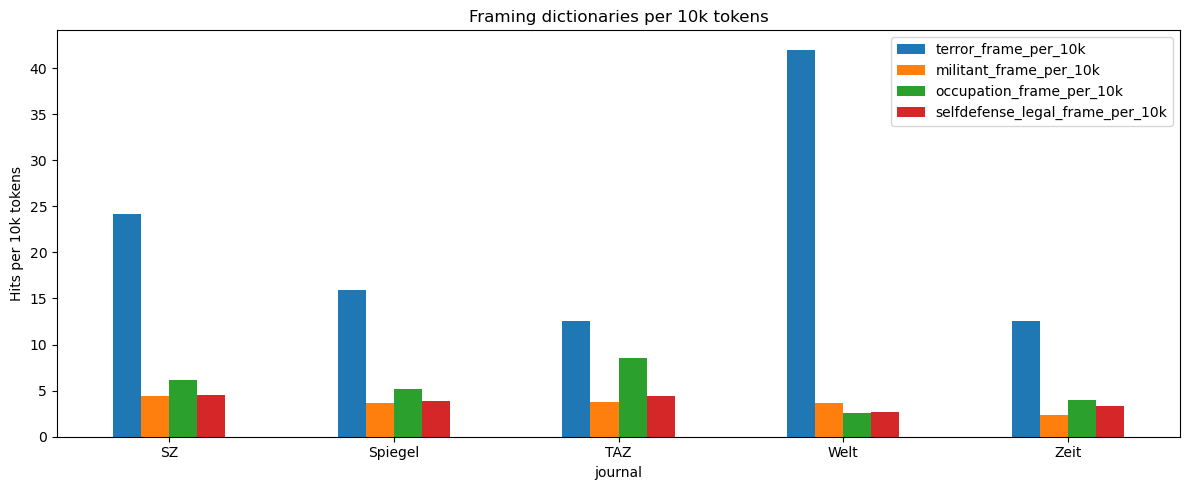

In [6]:
# Cell 2: Test 1 - Framing Ratios

# You can edit/expand these patterns
FRAME_SETS = {
    "terror_frame": [
        r"\bterror\w*\b", r"\bterrorismus\w*\b", r"\bterrorist\w*\b"
    ],
    "militant_frame": [
        r"\bmilitan\w*\b", r"\bkaempfer\w*\b", r"\bkämpfer\w*\b", r"\bbewaffnet\w*\b"
    ],
    "occupation_frame": [
        r"\bbesatz\w*\b", r"\bsiedl\w*\b", r"\bsiedler\w*\b"
    ],
    "selfdefense_legal_frame": [
        r"\bselbstverteidigung\w*\b", r"\bvoelkerrecht\w*\b", r"\bvölkerrecht\w*\b",
        r"\bkriegsverbrechen\w*\b", r"\bicc\b", r"\bicj\b"
    ],
}

compiled_frames = {
    k: [re.compile(p, flags=re.IGNORECASE) for p in pats]
    for k, pats in FRAME_SETS.items()
}

def count_frame_hits(text, regex_list):
    return sum(len(rx.findall(text)) for rx in regex_list)

rows = []
for _, r in docs_df.iterrows():
    t = r["text"]
    rec = {
        "journal": r["journal"],
        "file": r["file"],
        "tokens_n": r["tokens_n"]
    }
    for fname, regs in compiled_frames.items():
        rec[fname] = count_frame_hits(t, regs)
    rows.append(rec)

frame_df = pd.DataFrame(rows)

# Aggregate by journal
agg = frame_df.groupby("journal").sum(numeric_only=True)
for c in FRAME_SETS.keys():
    agg[c + "_per_10k"] = agg[c] / agg["tokens_n"] * 10000


# Add to Test 1 cell after `agg` is built

eps = 0.5  # smoothing to avoid unstable ratios with small counts

# Existing ratios (keep)
agg["terror_vs_militant_ratio"] = (agg["terror_frame"] + eps) / (agg["militant_frame"] + eps)
agg["occupation_vs_legal_ratio"] = (agg["occupation_frame"] + eps) / (agg["selfdefense_legal_frame"] + eps)

# Optional: log-ratios (more symmetric/interpretable)
agg["log_terror_vs_militant"] = np.log((agg["terror_frame"] + eps) / (agg["militant_frame"] + eps))
agg["log_occupation_vs_legal"] = np.log((agg["occupation_frame"] + eps) / (agg["selfdefense_legal_frame"] + eps))

# Optional: shares within paired frame families
agg["terror_share_in_security_pair"] = (
    (agg["terror_frame"] + eps) / (agg["terror_frame"] + agg["militant_frame"] + 2*eps)
)
agg["occupation_share_in_context_pair"] = (
    (agg["occupation_frame"] + eps) / (agg["occupation_frame"] + agg["selfdefense_legal_frame"] + 2*eps)
)

display(agg[[
    "terror_frame", "militant_frame", "terror_vs_militant_ratio", "log_terror_vs_militant", "terror_share_in_security_pair",
    "occupation_frame", "selfdefense_legal_frame", "occupation_vs_legal_ratio", "log_occupation_vs_legal", "occupation_share_in_context_pair"
]].sort_index())

# Plot example
ax = agg[[c for c in agg.columns if c.endswith("_per_10k")]].plot(kind="bar", figsize=(12,5))
ax.set_title("Framing dictionaries per 10k tokens")
ax.set_ylabel("Hits per 10k tokens")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,israeli_official_per_10k,hamas_official_per_10k,gaza_health_ministry_per_10k,un_ngo_per_10k,israel_to_hamas_attr_ratio,state_to_humanitarian_ratio
journal,,,,,,
SZ,0.345803,0.274748,0.028422,0.189481,1.258621,3.275000
Spiegel,0.414818,0.656591,0.031909,0.040500,0.631776,26.454545
TAZ,0.301761,0.230591,0.045549,0.338769,1.308642,1.571429
Welt,0.747041,0.830156,0.016821,0.127640,0.899881,12.356589
Zeit,0.310175,0.248140,0.012924,0.130532,1.250000,4.277228


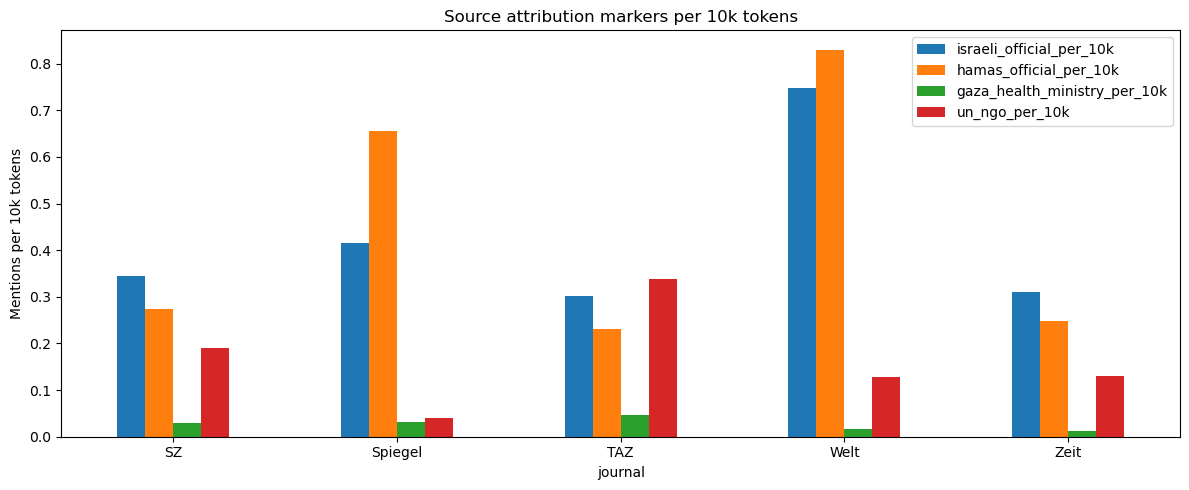

In [7]:
# Cell 3: Test 2 - Source Attribution Balance

SOURCE_PATTERNS = {
    "israeli_official": [
        r"\blaut\b.{0,40}\bidf\b",
        r"\blaut\b.{0,40}\bisrael\w*\s+(militaer|militär|armee|regierung)\b",
        r"\bnach angaben\b.{0,40}\b(idf|israel\w*)\b"
    ],
    "hamas_official": [
        r"\blaut\b.{0,40}\bhamas\b",
        r"\bnach angaben\b.{0,40}\bhamas\b"
    ],
    "gaza_health_ministry": [
        r"\blaut\b.{0,50}\bgesundheitsministerium\w*\b.{0,20}\bgaza\b",
        r"\bnach angaben\b.{0,50}\bgesundheitsministerium\w*\b.{0,20}\bgaza\b"
    ],
    "un_ngo": [
        r"\blaut\b.{0,40}\bun\b",
        r"\blaut\b.{0,40}\bvereinte nationen\b",
        r"\blaut\b.{0,40}\b(amnesty|human rights watch|ikrk|rotes kreuz|unrwa)\b"
    ]
}

compiled_sources = {
    k: [re.compile(p, flags=re.IGNORECASE|re.DOTALL) for p in pats]
    for k, pats in SOURCE_PATTERNS.items()
}

def count_source_attributions(text, regs):
    text_n = normalize_text(text)
    return sum(len(rx.findall(text_n)) for rx in regs)

rows = []
for _, r in docs_df.iterrows():
    rec = {"journal": r["journal"], "file": r["file"], "tokens_n": r["tokens_n"]}
    for sname, regs in compiled_sources.items():
        rec[sname] = count_source_attributions(r["text"], regs)
    rows.append(rec)

src_df = pd.DataFrame(rows)
src_agg = src_df.groupby("journal").sum(numeric_only=True)

for c in SOURCE_PATTERNS.keys():
    src_agg[c + "_per_10k"] = src_agg[c] / src_agg["tokens_n"] * 10000

# Balance metrics
eps = 1e-6
src_agg["israel_to_hamas_attr_ratio"] = (src_agg["israeli_official"] + eps) / (src_agg["hamas_official"] + eps)
src_agg["state_to_humanitarian_ratio"] = (src_agg["israeli_official"] + src_agg["hamas_official"] + eps) / (src_agg["un_ngo"] + eps)

display_cols = [c for c in src_agg.columns if c.endswith("_per_10k")] + [
    "israel_to_hamas_attr_ratio", "state_to_humanitarian_ratio"
]
display(src_agg[display_cols].sort_index())

ax = src_agg[[c for c in src_agg.columns if c.endswith("_per_10k")]].plot(kind="bar", figsize=(12,5))
ax.set_title("Source attribution markers per 10k tokens")
ax.set_ylabel("Mentions per 10k tokens")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
# Expanded Test 1: Harm Event Extraction with richer perpetrator schema
import re
import pandas as pd
import numpy as np

# ---------------------------
# Helpers
# ---------------------------
def normalize_text(s: str) -> str:
    return s.lower().replace("ß", "ss")

def split_sentences(text: str):
    return re.split(r'(?<=[\.\!\?])\s+', text.strip())

def compile_dict(d):
    return {k: [re.compile(p, flags=re.IGNORECASE) for p in pats] for k, pats in d.items()}

def find_matches(rx_dict, text):
    out = []
    for label, regs in rx_dict.items():
        if any(rx.search(text) for rx in regs):
            out.append(label)
    return out

# ---------------------------
# Event dictionaries
# ---------------------------
EVENT_PATTERNS = {
    "killing": [
        r"\b(getoetet|getötet|erschossen|umgebracht|toedlich|tödlich|starb|gestorben|tot)\b"
    ],
    "injury_maiming": [
        r"\b(verletzt|verwundet|verstummelt|verstümmelt)\b"
    ],
    "arrest_detention": [
        r"\b(festgenommen|verhaftet|inhaftiert|in haft|festgehalten|detention)\b"
    ],
    "disappearance": [
        r"\b(verschwunden|zwangsverschwinden|enforced disappearance|verschleppt)\b"
    ],
    "threat_harassment": [
    r"\b(bedroh\w*|eingeschuechtert|eingeschüchtert|schikane|belaestig\w*|belästig\w*)\b.{0,40}\b(journalist\w*|reporter\w*|medien\w*|familie|angehoerig\w*|angehörig\w*)\b",
    r"\b(journalist\w*|reporter\w*|medien\w*|familie|angehoerig\w*|angehörig\w*)\b.{0,40}\b(bedroh\w*|eingeschuechtert|eingeschüchtert|schikane|belaestig\w*|belästig\w*)\b"
    ],
    "infrastructure_destruction": [
        r"\b(zerstoer\w*|zerstör\w*|bombard\w*|angegriffen|beschossen)\b.{0,60}\b(redaktion|sender|studio|medienhaus|pressebuero|pressebüro|agentur|funkhaus|telekommunikation|internet|netz)\b",
        r"\b(telekommunikation|internet|netz)\b.{0,40}\b(ausfall|unterbrochen|abgeschaltet|blackout)\b"
    ],
    "equipment_confiscation": [
        r"\b(konfisziert|beschlagnahmt|sichergestellt|entzogen)\b.{0,40}\b(kamera|ausruestung|ausrüstung|equipment|telefon|laptop|material)\b",
        r"\b(kamera|ausruestung|ausrüstung|equipment|telefon|laptop|material)\b.{0,40}\b(konfisziert|beschlagnahmt|sichergestellt|entzogen)\b"
    ],
    "foreign_press_exclusion": [
        r"\b(ausgewiesen|nicht zugelassen|zugang verweigert|einreiseverbot|excluded|expelled|akkreditierung entzogen)\b.{0,60}\b(auslandsjournalist\w*|auslaendisch\w* journalist\w*|foreign journalist\w*|internationale presse)\b"
    ],
    "label_terrorist_or_hamas": [
        r"\b(journalist\w*|reporter\w*|medien\w*)\b.{0,50}\b(terrorist\w*|hamas[-\s]?kaempfer|hamas[-\s]?kämpfer|mit hamas verbunden)\b",
        r"\b(terrorist\w*|hamas[-\s]?kaempfer|hamas[-\s]?kämpfer|mit hamas verbunden)\b.{0,50}\b(journalist\w*|reporter\w*|medien\w*)\b"
    ],
    "family_targeting": [
        r"\b(familie|angehoerig\w*|angehörig\w*|kind\w*|ehefrau|ehemann)\b.{0,50}\b(getoetet|getötet|verletzt|bedroh\w*|festgenommen|verhaftet)\b"
    ]
}

TARGET_PATTERNS = {
    "journalist_media_worker": [
        r"\b(journalist\w*|reporter\w*|fotograf\w*|kameramann|korrespondent\w*|medienarbeiter\w*|pressevertreter\w*)\b"
    ],
    "media_institution": [
        r"\b(redaktion\w*|sender\w*|medienhaus|agentur|nachrichtenbuero|nachrichtenbüro|pressebuero|pressebüro|studio)\b"
    ],
    "family_member": [
        r"\b(familie|angehoerig\w*|angehörig\w*|kind\w*|ehefrau|ehemann)\b"
    ]
}

# ---------------------------
# Expanded perpetrator schema
# ---------------------------
PERPETRATOR_PATTERNS = {
    "israeli_state_forces": [
        r"\b(idf|israelisch\w* (armee|militaer|militär|streitkraefte|streitkräfte|soldat\w*|luftwaffe)|israelische\w* (kraefte|kräfte|polizei|geheimdienst\w*)|shin bet)\b"
    ],
    "palestinian_armed_groups": [
        r"\b(hamas|qassam|islamischer dschihad|palestinian islamic jihad|pij|al[-\s]?qassam|bewaffnete palastinensische gruppen|bewaffnete palästinensische gruppen)\b"
    ],
    "israeli_settlers": [
        r"\b(siedler\w*|israelische\w* siedler\w*|settler\w*)\b"
    ],
    "other_state_or_foreign_forces": [
        r"\b(aegyptisch\w* kraefte|ägyptisch\w* kräfte|us[-\s]?militaer|us[-\s]?militär|iranisch\w* kraefte|huthi\w*|hezbollah)\b"
    ],
    "civilian_mob_or_unknown_gunmen": [
        r"\b(unbekannte bewaffnete|bewaffnete maenner|bewaffnete männer|mob|lynch)\b"
    ]
}

# ---------------------------
# Attribution/source schema
# ---------------------------
ATTRIBUTION_PATTERNS = {
    "according_to_israeli_officials": [
        r"\b(laut|nach angaben von)\b.{0,60}\b(idf|israel\w* (armee|regierung|militaer|militär|polizei)|sprecher\w* der israel\w*)\b"
    ],
    "according_to_palestinian_officials_or_groups": [
        r"\b(laut|nach angaben von)\b.{0,60}\b(hamas|gesundheitsministerium\w*.*gaza|palastinens\w* behoerden|palästinens\w* behörden)\b"
    ],
    "according_to_un_ngo_intl": [
        r"\b(laut|nach angaben von)\b.{0,60}\b(un|vereinte nationen|unrwa|amnesty|human rights watch|ikrk|rotes kreuz|cpj|rsf|reporter ohne grenzen)\b"
    ],
    "according_to_witnesses": [
        r"\b(laut|nach)\b.{0,40}\b(zeugen|augenzeugen|witnesses)\b"
    ]
}
# --- add to TARGET_PATTERNS ---
TARGET_PATTERNS.update({
    "palestinian_people": [
        r"\bpalastinens\w*\b", r"\bpalästinens\w*\b", r"\bgaza\w*\b"
    ],
    "israeli_people": [
        r"\bisraelis?\b", r"\bisraelisch\w* zivil\w*\b"
    ],
    "generic_civilians": [
        r"\b(zivilist\w*|menschen|personen|opfer|bevoelkerung|bevölkerung)\b"
    ]
})

# --- add to PERPETRATOR_PATTERNS ---
PERPETRATOR_PATTERNS.update({
    "security_forces_generic": [
        r"\bsicherheitskraefte\b", r"\bsicherheitskräfte\b", r"\bmilitaer\b", r"\bmilitär\b"
    ],
    "attackers_unspecified": [
        r"\b(bombenanschlag|anschlag|attentat|raketenangriff|beschuss)\b",
        r"\b(entfuehrt|entführt)\b"
    ]
})

# --- add to ATTRIBUTION_PATTERNS (your UN phrase wasn't always caught) ---
ATTRIBUTION_PATTERNS["according_to_un_ngo_intl"] += [
    r"\bnach angaben der vereinten nationen\b",
    r"\blaut einem bericht der vereinten nationen\b"
]

EVENT_RX = compile_dict(EVENT_PATTERNS)
TARGET_RX = compile_dict(TARGET_PATTERNS)
PERP_RX = compile_dict(PERPETRATOR_PATTERNS)
ATTR_RX = compile_dict(ATTRIBUTION_PATTERNS)

# ---------------------------
# Extract
# ---------------------------
rows = []
for _, doc in docs_df.iterrows():
    for sent in split_sentences(doc["text"]):
        s_raw = sent.strip()
        if len(s_raw) < 20:
            continue
        s = normalize_text(s_raw)

        events = find_matches(EVENT_RX, s)
        if not events:
            continue

        targets = find_matches(TARGET_RX, s)
        perps = find_matches(PERP_RX, s)
        attrs = find_matches(ATTR_RX, s)

        # post-processing for perpetrator labels
        if len(perps) == 0:
            perps = ["unspecified_perpetrator"]
        elif len(perps) > 1:
            perps = perps + ["multiple_or_disputed_perpetrator_mentions"]

        if len(targets) == 0:
            targets = ["unspecified_target"]
        if len(attrs) == 0:
            attrs = ["no_explicit_attribution"]

        rows.append({
            "journal": doc["journal"],
            "file": doc["file"],
            "sentence": s_raw,
            "events": events,
            "targets": targets,
            "perpetrators": perps,
            "attributions": attrs
        })

events_df = pd.DataFrame(rows)
print("Extracted event sentences:", len(events_df))
display(events_df.head(8))

# ---------------------------
# Summaries
# ---------------------------
def summarize_exploded(df, list_col):
    return (df[["journal", list_col]]
            .explode(list_col)
            .groupby(["journal", list_col]).size()
            .rename("n")
            .reset_index())

event_summary = summarize_exploded(events_df, "events")
perp_summary = summarize_exploded(events_df, "perpetrators")
target_summary = summarize_exploded(events_df, "targets")
attr_summary = summarize_exploded(events_df, "attributions")

print("\nPerpetrator counts by journal:")
display(perp_summary.pivot(index="perpetrators", columns="journal", values="n").fillna(0).astype(int))

print("\nEvent counts by journal:")
display(event_summary.pivot(index="events", columns="journal", values="n").fillna(0).astype(int))

print("\nAttribution counts by journal:")
display(attr_summary.pivot(index="attributions", columns="journal", values="n").fillna(0).astype(int))

# ---------------------------
# Optional: normalized perpetrator shares within each journal
# ---------------------------
perp_mat = perp_summary.pivot(index="journal", columns="perpetrators", values="n").fillna(0)
perp_share = perp_mat.div(perp_mat.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
print("\nPerpetrator share within each journal:")
display(perp_share.round(3))

# ---------------------------
# Save audit file
# ---------------------------
events_df.to_csv("harm_event_sentences_expanded_audit.csv", index=False, encoding="utf-8")
print("Saved: harm_event_sentences_expanded_audit.csv")

Extracted event sentences: 33830


,journal,file,sentence,events,targets,perpetrators,attributions
0,SZ,2023_10_07_antworten-auf-die-wichtigsten-frage...,Mindestens 200 Israelis starben bei den Angrif...,[injury_maiming],[israeli_people],[unspecified_perpetrator],[no_explicit_attribution]
1,SZ,2023_10_07_chronologie-eines-schier-endlosen-k...,"Tausende Menschen sind gestorben, etliche Bemü...",[killing],[generic_civilians],[unspecified_perpetrator],[no_explicit_attribution]
2,SZ,2023_10_07_chronologie-eines-schier-endlosen-k...,Juli 2014Wieder Spannungen zwischen Gaza und I...,[killing],[palestinian_people],[attackers_unspecified],[no_explicit_attribution]
3,SZ,2023_10_07_chronologie-eines-schier-endlosen-k...,"Auf beiden Seiten sterben mehrere Menschen, Hu...",[injury_maiming],[generic_civilians],[unspecified_perpetrator],[no_explicit_attribution]
4,SZ,2023_10_07_chronologie-eines-schier-endlosen-k...,Bei einem Bombenanschlag in Jerusalem stirbt e...,[injury_maiming],[generic_civilians],[attackers_unspecified],[no_explicit_attribution]
5,SZ,2023_10_07_chronologie-eines-schier-endlosen-k...,Nach Angaben der Vereinten Nationen werden bis...,[killing],"[palestinian_people, israeli_people]",[unspecified_perpetrator],[according_to_un_ngo_intl]
6,SZ,2023_10_07_chronologie-eines-schier-endlosen-k...,Bis August werden laut einem Bericht der Verei...,[killing],"[palestinian_people, israeli_people]",[unspecified_perpetrator],[according_to_un_ngo_intl]
7,SZ,2023_10_08_der-meister-der-m-rtyrer.txt,Nun haben israelische Streitkräfte den meistge...,[killing],[unspecified_target],[israeli_state_forces],[no_explicit_attribution]



Perpetrator counts by journal:


journal,SZ,Spiegel,TAZ,Welt,Zeit
perpetrators,,,,,
attackers_unspecified,59,210,71,352,157
civilian_mob_or_unknown_gunmen,5,9,4,2,2
israeli_settlers,14,49,42,32,30
israeli_state_forces,126,461,187,703,289
multiple_or_disputed_perpetrator_mentions,45,205,91,345,147
other_state_or_foreign_forces,4,35,5,38,31
palestinian_armed_groups,364,1301,292,1971,687
security_forces_generic,31,157,79,257,98
unspecified_perpetrator,1707,7893,2842,9233,4929



Event counts by journal:


...


Attribution counts by journal:


journal,SZ,Spiegel,TAZ,Welt,Zeit
attributions,,,,,
according_to_israeli_officials,1,19,5,24,10
according_to_palestinian_officials_or_groups,13,90,23,81,35
according_to_un_ngo_intl,11,17,23,16,25
according_to_witnesses,0,6,0,0,0
no_explicit_attribution,2236,9755,3373,12076,5999



Perpetrator share within each journal:


perpetrators,attackers_unspecified,civilian_mob_or_unknown_gunmen,israeli_settlers,israeli_state_forces,multiple_or_disputed_perpetrator_mentions,other_state_or_foreign_forces,palestinian_armed_groups,security_forces_generic,unspecified_perpetrator
journal,,,,,,,,,
SZ,0.025,0.002,0.006,0.054,0.019,0.002,0.155,0.013,0.725
Spiegel,0.020,0.001,0.005,0.045,0.020,0.003,0.126,0.015,0.765
TAZ,0.020,0.001,0.012,0.052,0.025,0.001,0.081,0.022,0.787
Welt,0.027,0.000,0.002,0.054,0.027,0.003,0.152,0.020,0.714
Zeit,0.025,0.000,0.005,0.045,0.023,0.005,0.108,0.015,0.774


Saved: harm_event_sentences_expanded_audit.csv


In [11]:
# Add one-hot event columns + optional primary_event before CSV export

# 1) one-hot columns
all_event_labels = sorted({e for lst in events_df["events"] for e in (lst if isinstance(lst, list) else [])})
for e in all_event_labels:
    events_df[f"event__{e}"] = events_df["events"].apply(lambda lst: int(isinstance(lst, list) and e in lst))

# 2) optional primary event (first matched)
events_df["primary_event"] = events_df["events"].apply(
    lambda lst: lst[0] if isinstance(lst, list) and len(lst) > 0 else "none"
)

# 3) export
events_df.to_csv("harm_event_sentences_expanded_audit_with_event_columns.csv", index=False, encoding="utf-8")
print("Saved harm_event_sentences_expanded_audit_with_event_columns.csv")

Saved harm_event_sentences_expanded_audit_with_event_columns.csv


In [12]:
criteria_text = """
CSV SCHEMA + CODING CRITERIA
============================

File purpose
------------
This CSV contains sentence-level extractions from newspaper text for event coding related to harms against journalists/media ecosystem and related conflict reporting.

Unit of analysis
----------------
- One row = one sentence that matched at least one EVENT pattern.

Column definitions
------------------

journal
- Outlet label from JOURNAL_DIRS key (e.g., SZ, Zeit, Spiegel, TAZ).

file
- Source text filename.

sentence
- Original sentence text (as split by regex sentence splitter).

events
- List of matched EVENT categories.
- A sentence may contain multiple event labels.

targets
- List of matched target categories (who is affected).
- If no target pattern is found, value is ['unspecified_target'].

perpetrators
- List of matched perpetrator categories (who allegedly committed the act).
- If no perpetrator pattern is found, value is ['unspecified_perpetrator'].
- If multiple perpetrator categories matched, list may include multiple labels.

attributions
- List of matched source-attribution categories (e.g., 'according_to_un_ngo_intl').
- If no explicit attribution pattern is found, value is ['no_explicit_attribution'].

event__<label>  (optional one-hot columns)
- Binary indicator (0/1) that event label is present in the row.

primary_event (optional)
- First event label in the matched events list (or 'none' if empty).

Event category criteria
-----------------------
killing
- Terms indicating death/homicide (e.g., getötet, erschossen, tot, gestorben).

injury_maiming
- Terms indicating injury/wounding/mutilation.

arrest_detention
- Terms indicating arrest, detention, imprisonment.

disappearance
- Terms indicating disappearance/abduction where fate/location is unknown.

threat_harassment
- Terms indicating threat/intimidation/harassment (depending on pattern constraints).

infrastructure_destruction
- Attack/destruction/disruption references tied to media/telecom infrastructure.

equipment_confiscation
- Confiscation/seizure/removal of journalistic equipment.

foreign_press_exclusion
- Exclusion/expulsion/access denial of foreign journalists/press.

label_terrorist_or_hamas
- Statements labeling journalists/media workers as terrorist/Hamas-fighter etc.

family_targeting
- Harm/threat/arrest language targeting family members.

Target category criteria
------------------------
journalist_media_worker
- Mentions of journalists/reporters/photojournalists/correspondents/media workers.

media_institution
- Mentions of newsroom/media house/agency/studio/press office.

family_member
- Mentions of family/relatives/spouse/children.

generic_civilians / palestinian_people / israeli_people (if enabled)
- Broader civilian identity group mentions.

Perpetrator category criteria
-----------------------------
israeli_state_forces
- IDF, Israeli military/police/security/intelligence references.

palestinian_armed_groups
- Hamas/PIJ/Qassam/related armed group references.

israeli_settlers
- Settler actor references.

other_state_or_foreign_forces
- Other named state/non-local armed actors.

attackers_unspecified / civilian_mob_or_unknown_gunmen
- Generic attacker descriptions without clear institutional actor.

unspecified_perpetrator
- No perpetrator cue detected in sentence.

Attribution category criteria
-----------------------------
according_to_israeli_officials
according_to_palestinian_officials_or_groups
according_to_un_ngo_intl
according_to_witnesses
no_explicit_attribution

Method limitations
------------------
- Regex-based matching: sensitive to wording and may miss paraphrases.
- Sentence-level scope: cross-sentence coreference may be missed.
- Categories indicate textual mention patterns, not legal findings.
- Manual validation is required before substantive claims.
"""

with open("coding_criteria.txt", "w", encoding="utf-8") as f:
    f.write(criteria_text.strip() + "\n")

print("Saved coding_criteria.txt")

Saved coding_criteria.txt


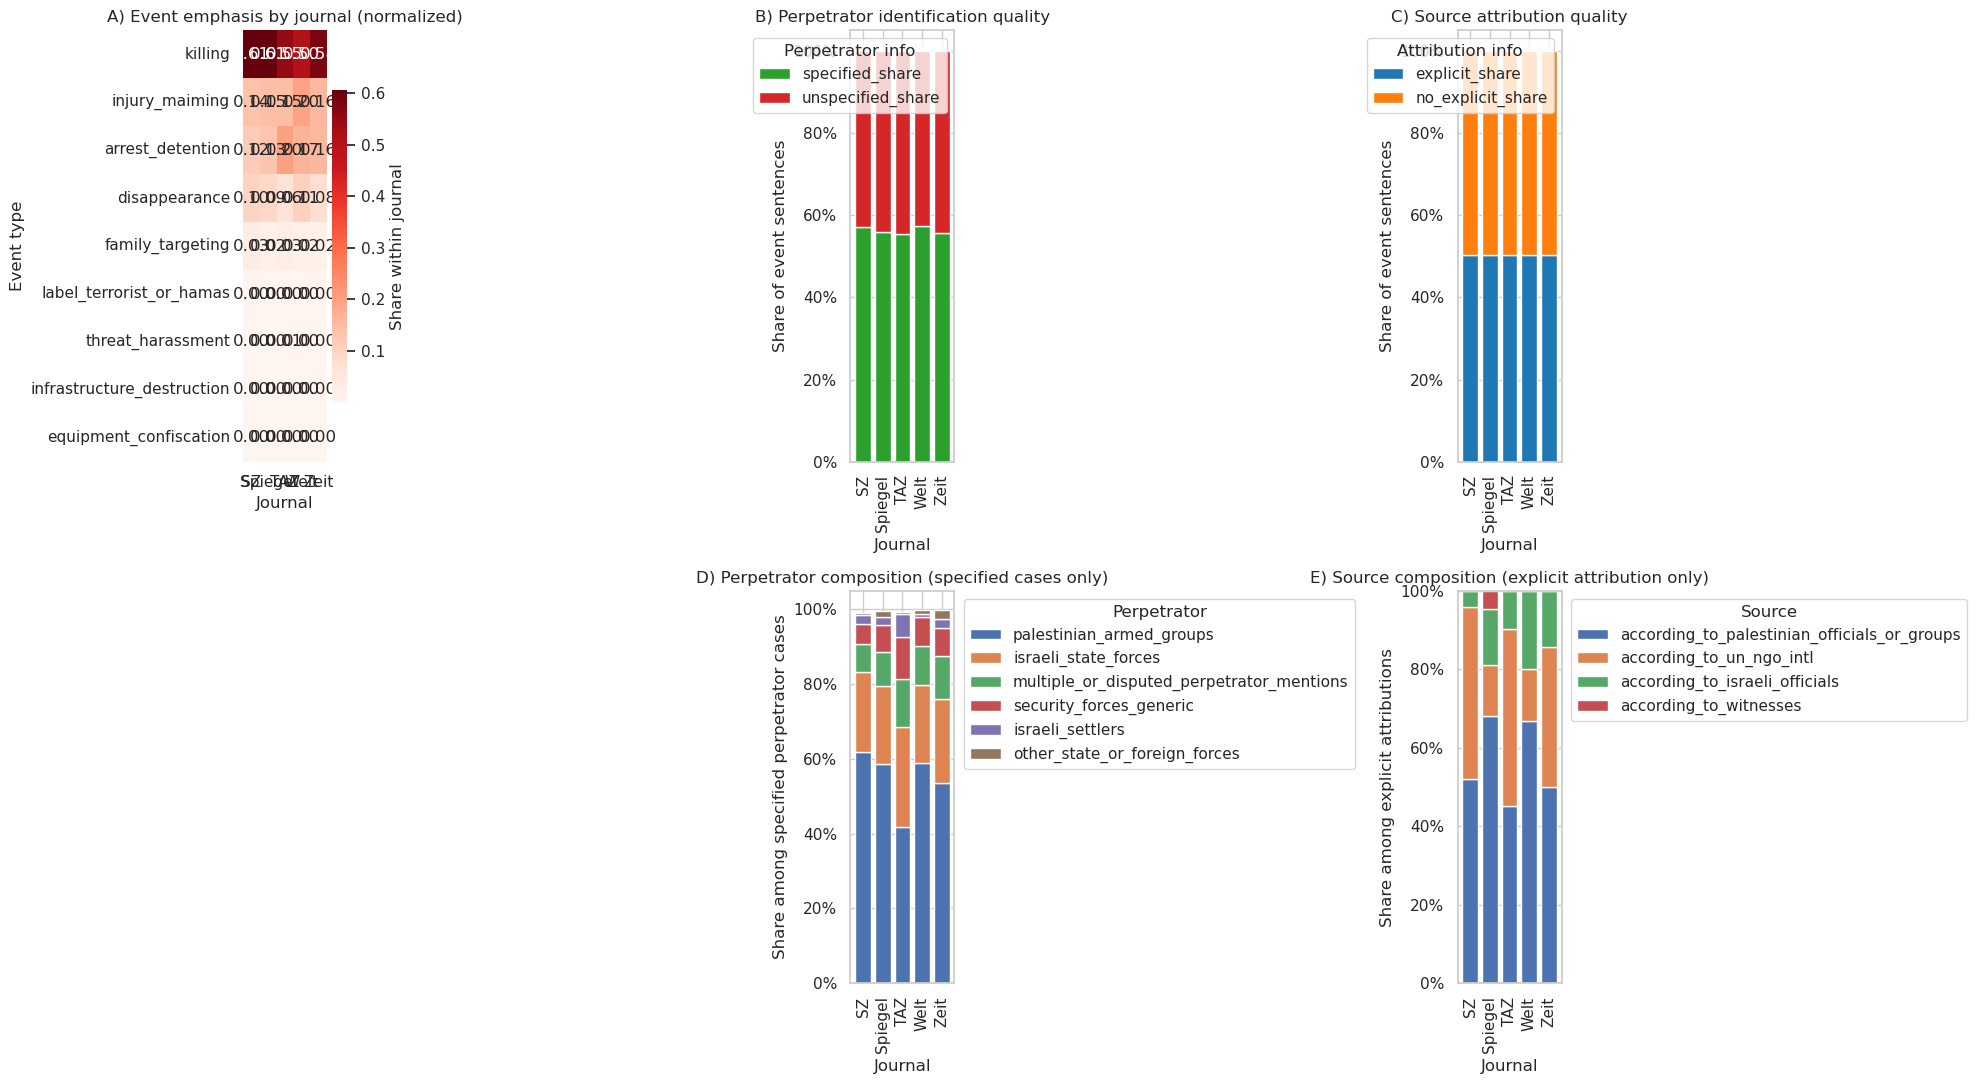

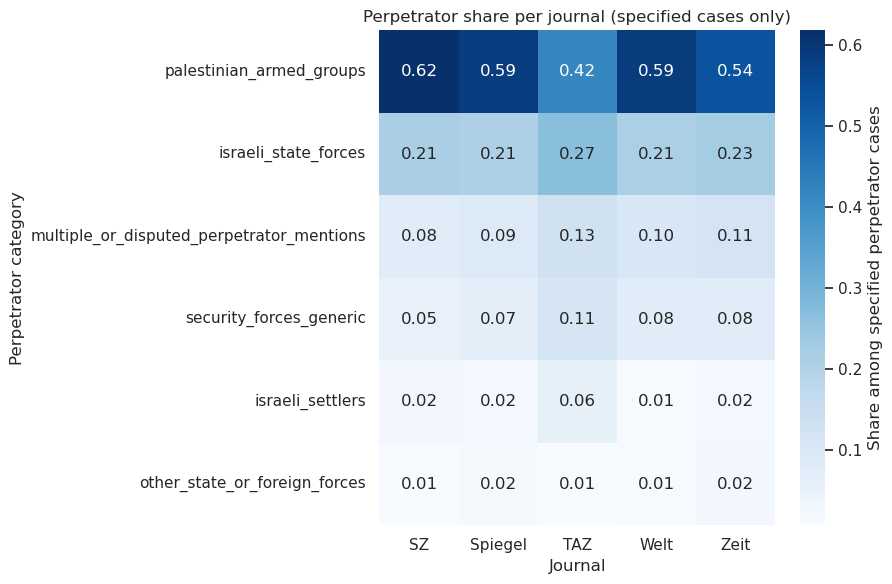

In [9]:
# Improved visualization for Test 1:
# - separates "coverage quality" from "who is named"
# - plots perpetrator shares among specified cases only
# Assumes events_df with list columns: events, perpetrators, attributions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid")

def explode_counts(df, col):
    return (
        df[["journal", col]]
        .explode(col)
        .groupby(["journal", col]).size()
        .rename("n")
        .reset_index()
    )

# ---------------------------
# 1) Event heatmap (kept, but cleaner)
# ---------------------------
event_counts = explode_counts(events_df, "events")
event_mat = event_counts.pivot(index="events", columns="journal", values="n").fillna(0)

# normalize within journal (column)
event_mat_colnorm = event_mat.div(event_mat.sum(axis=0).replace(0, np.nan), axis=1).fillna(0)

# reorder events by overall prevalence
event_order = event_mat.sum(axis=1).sort_values(ascending=False).index
event_mat_colnorm = event_mat_colnorm.loc[event_order]

# ---------------------------
# 2) Perpetrator: specified vs unspecified, then specified composition
# ---------------------------
perp_counts = explode_counts(events_df, "perpetrators")
perp_mat = perp_counts.pivot(index="journal", columns="perpetrators", values="n").fillna(0)

# robust handling of unspecified bucket names
unspec_perp_cols = [c for c in perp_mat.columns if "unspecified" in c.lower()]
if len(unspec_perp_cols) == 0:
    perp_mat["unspecified_perpetrator"] = 0
    unspec_perp_cols = ["unspecified_perpetrator"]

perp_mat["unspecified_total"] = perp_mat[unspec_perp_cols].sum(axis=1)
perp_mat["total"] = perp_mat.sum(axis=1)

perp_quality = pd.DataFrame(index=perp_mat.index)
perp_quality["specified_share"] = (perp_mat["total"] - perp_mat["unspecified_total"]) / perp_mat["total"].replace(0, np.nan)
perp_quality["unspecified_share"] = perp_mat["unspecified_total"] / perp_mat["total"].replace(0, np.nan)
perp_quality = perp_quality.fillna(0)

# composition among specified only
perp_spec_cols = [c for c in perp_mat.columns if c not in (unspec_perp_cols + ["unspecified_total", "total"])]
perp_spec = perp_mat[perp_spec_cols].copy()
perp_spec_share = perp_spec.div(perp_spec.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

# keep top categories globally for readability
top_perp_spec = perp_spec.sum(axis=0).sort_values(ascending=False).head(6).index
perp_spec_share_plot = perp_spec_share[top_perp_spec]

# ---------------------------
# 3) Attribution: explicit vs no-explicit, then explicit composition
# ---------------------------
attr_counts = explode_counts(events_df, "attributions")
attr_mat = attr_counts.pivot(index="journal", columns="attributions", values="n").fillna(0)

no_attr_cols = [c for c in attr_mat.columns if "no_explicit" in c.lower()]
if len(no_attr_cols) == 0:
    attr_mat["no_explicit_attribution"] = 0
    no_attr_cols = ["no_explicit_attribution"]

attr_mat["no_attr_total"] = attr_mat[no_attr_cols].sum(axis=1)
attr_mat["total"] = attr_mat.sum(axis=1)

attr_quality = pd.DataFrame(index=attr_mat.index)
attr_quality["explicit_share"] = (attr_mat["total"] - attr_mat["no_attr_total"]) / attr_mat["total"].replace(0, np.nan)
attr_quality["no_explicit_share"] = attr_mat["no_attr_total"] / attr_mat["total"].replace(0, np.nan)
attr_quality = attr_quality.fillna(0)

attr_exp_cols = [c for c in attr_mat.columns if c not in (no_attr_cols + ["no_attr_total", "total"])]
attr_exp = attr_mat[attr_exp_cols].copy()
attr_exp_share = attr_exp.div(attr_exp.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

top_attr_exp = attr_exp.sum(axis=0).sort_values(ascending=False).head(6).index
attr_exp_share_plot = attr_exp_share[top_attr_exp]

# ---------------------------
# FIGURE 1: Main summary (interpretable)
# ---------------------------
fig, axes = plt.subplots(2, 3, figsize=(20, 11), gridspec_kw={"height_ratios":[1.1, 1]})

# A) Events heatmap
ax = axes[0,0]
sns.heatmap(
    event_mat_colnorm, cmap="Reds", annot=True, fmt=".2f",
    cbar_kws={"label": "Share within journal"}, ax=ax
)
ax.set_title("A) Event emphasis by journal (normalized)")
ax.set_xlabel("Journal")
ax.set_ylabel("Event type")

# B) Perp quality: specified vs unspecified
ax = axes[0,1]
perp_quality[["specified_share","unspecified_share"]].plot(kind="bar", stacked=True, ax=ax, width=0.8, color=["#2ca02c","#d62728"])
ax.set_title("B) Perpetrator identification quality")
ax.set_ylabel("Share of event sentences")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Journal")
ax.legend(loc="upper right", title="Perpetrator info")

# C) Attribution quality: explicit vs none
ax = axes[0,2]
attr_quality[["explicit_share","no_explicit_share"]].plot(kind="bar", stacked=True, ax=ax, width=0.8, color=["#1f77b4","#ff7f0e"])
ax.set_title("C) Source attribution quality")
ax.set_ylabel("Share of event sentences")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Journal")
ax.legend(loc="upper right", title="Attribution info")

# D) Perp composition among specified only
ax = axes[1,1]
perp_spec_share_plot.plot(kind="bar", stacked=True, ax=ax, width=0.8)
ax.set_title("D) Perpetrator composition (specified cases only)")
ax.set_ylabel("Share among specified perpetrator cases")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Journal")
ax.legend(title="Perpetrator", bbox_to_anchor=(1.02, 1), loc="upper left")

# E) Attribution composition among explicit only
ax = axes[1,2]
attr_exp_share_plot.plot(kind="bar", stacked=True, ax=ax, width=0.8)
ax.set_title("E) Source composition (explicit attribution only)")
ax.set_ylabel("Share among explicit attributions")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Journal")
ax.legend(title="Source", bbox_to_anchor=(1.02, 1), loc="upper left")

# empty slot for balance
axes[1,0].axis("off")

plt.tight_layout()
plt.show()

# ---------------------------
# FIGURE 2: Nice dedicated plot from perpetrator share table
# (specified-only heatmap; very publication-friendly)
# ---------------------------
plt.figure(figsize=(9,6))
sns.heatmap(
    perp_spec_share_plot.T,  # perpetrators as rows for readability
    annot=True, fmt=".2f", cmap="Blues",
    cbar_kws={"label":"Share among specified perpetrator cases"}
)
plt.title("Perpetrator share per journal (specified cases only)")
plt.xlabel("Journal")
plt.ylabel("Perpetrator category")
plt.tight_layout()
plt.show()

Target counts by journal:


targets,family_member,generic_civilians,israeli_people,journalist_media_worker,media_institution,palestinian_people,unspecified_target
journal,,,,,,,
SZ,236,548,80,46,17,606,1136
Spiegel,725,2867,182,172,49,2276,5064
TAZ,293,794,73,127,24,657,1895
Welt,698,3707,238,207,106,3167,5940
Zeit,391,1607,87,113,23,965,3503


Target shares within journal:


targets,family_member,generic_civilians,israeli_people,journalist_media_worker,media_institution,palestinian_people,unspecified_target
journal,,,,,,,
SZ,8.84,20.53,3.00,1.72,0.64,22.71,42.56
Spiegel,6.40,25.29,1.61,1.52,0.43,20.08,44.68
TAZ,7.58,20.55,1.89,3.29,0.62,17.01,49.06
Welt,4.96,26.36,1.69,1.47,0.75,22.52,42.24
Zeit,5.85,24.02,1.30,1.69,0.34,14.43,52.37


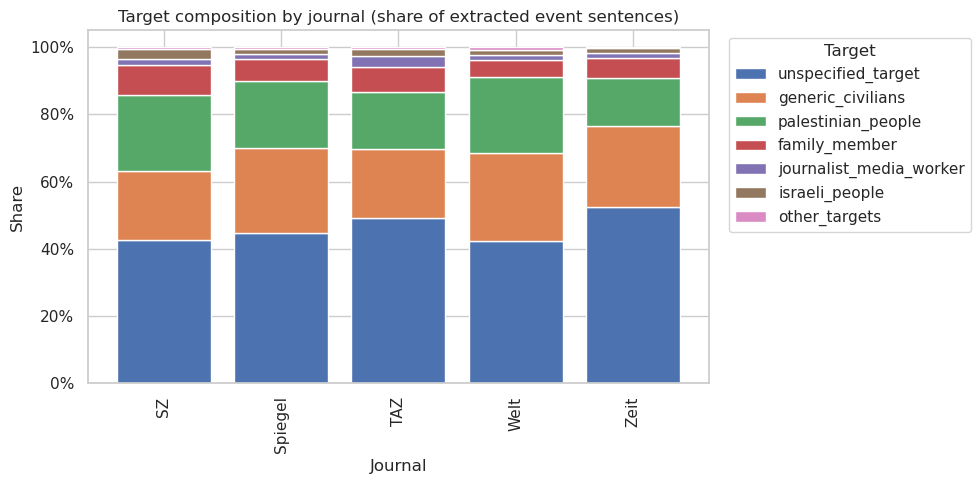

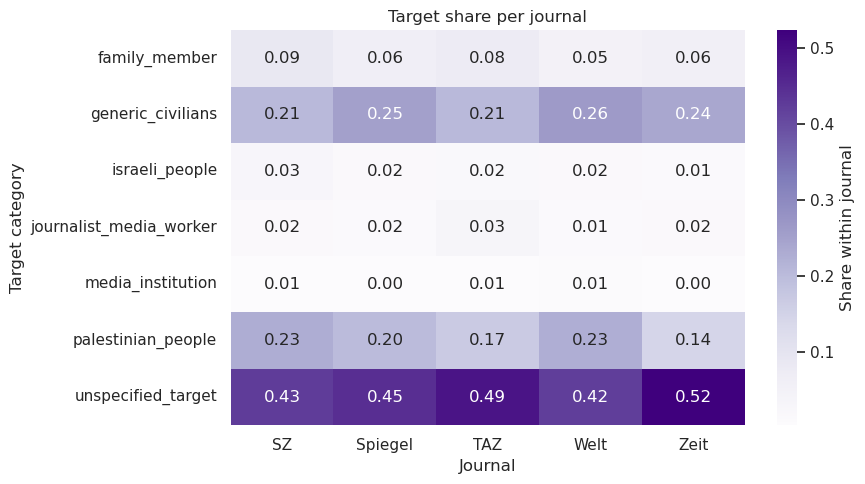

In [10]:
# --- Targets: summary + plots ---
# Assumes events_df has list column "targets"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

def explode_counts(df, col):
    return (df[["journal", col]]
            .explode(col)
            .groupby(["journal", col]).size()
            .rename("n")
            .reset_index())

target_counts = explode_counts(events_df, "targets")
target_mat = target_counts.pivot(index="journal", columns="targets", values="n").fillna(0)

# ---- Summary table (counts) ----
print("Target counts by journal:")
display(target_mat.astype(int))

# ---- Summary table (shares within journal) ----
target_share = target_mat.div(target_mat.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
print("Target shares within journal:")
display((target_share * 100).round(2))

# ---- Plot 1: 100% stacked bars (composition) ----
# optional: keep top categories and group rest as 'other'
top_k = 6
top_targets = target_mat.sum(axis=0).sort_values(ascending=False).head(top_k).index.tolist()

target_share_plot = target_share.copy()
other_cols = [c for c in target_share_plot.columns if c not in top_targets]
if other_cols:
    target_share_plot["other_targets"] = target_share_plot[other_cols].sum(axis=1)
    target_share_plot = target_share_plot[top_targets + ["other_targets"]]
else:
    target_share_plot = target_share_plot[top_targets]

ax = target_share_plot.plot(kind="bar", stacked=True, figsize=(10,5), width=0.8)
ax.set_title("Target composition by journal (share of extracted event sentences)")
ax.set_ylabel("Share")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("Journal")
ax.legend(title="Target", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---- Plot 2: Heatmap (great for reports) ----
# transpose so rows=target categories
plt.figure(figsize=(9,5))
sns.heatmap(
    target_share.T, annot=True, fmt=".2f", cmap="Purples",
    cbar_kws={"label": "Share within journal"}
)
plt.title("Target share per journal")
plt.xlabel("Journal")
plt.ylabel("Target category")
plt.tight_layout()
plt.show()